# ARIA — Multimodal Financial Intelligence Platform
### BTP Evaluation Notebook · IIIT Sri City

Run cells in order. Each cell demonstrates one component of the system.

In [ ]:
# Setup — run this first
import os, sys, warnings
os.chdir(r'E:\BTP\aria')
sys.path.insert(0, r'E:\BTP\aria')
os.environ['CUDA_VISIBLE_DEVICES'] = ''   # ML models use CPU; GPU reserved for LLM
warnings.filterwarnings('ignore')
print('Setup complete. Working dir:', os.getcwd())

## 1. Tax Rules Engine (FY 2025-26)
Deterministic computation — no ML, pure financial logic.

In [1]:
from aria.module1_personal_finance.tax_rules import tax_new, tax_old

incomes = [500_000, 700_000, 1_000_000, 1_200_000, 1_500_000]
print(f'{'Income':>15}  {'New Regime':>12}  {'Old Regime (80C=1.5L)':>22}  {'Save with Old':>14}')
print('-'*70)
for inc in incomes:
    tn = tax_new(inc)
    to = tax_old(inc, 150_000)
    saving = tn - to
    print(f'Rs.{inc:>10,.0f}  Rs.{tn:>9,.0f}  Rs.{to:>19,.0f}  Rs.{saving:>11,.0f}')

         Income    New Regime   Old Regime (80C=1.5L)   Save with Old
----------------------------------------------------------------------
Rs.   500,000  Rs.    6,500  Rs.              2,600  Rs.      3,900
Rs.   700,000  Rs.   16,900  Rs.             13,000  Rs.      3,900
Rs. 1,000,000  Rs.   44,200  Rs.             75,400  Rs.    -31,200
Rs. 1,200,000  Rs.   71,500  Rs.            117,000  Rs.    -45,500
Rs. 1,500,000  Rs.  130,000  Rs.            210,600  Rs.    -80,600


## 2. SIP & EMI Calculator

In [2]:
from aria.module1_personal_finance.sip_emi_calc import sip_future_value, emi, sip_required

print('=== SIP Future Value ===')
for monthly, years, rate in [(5000,10,12),(10000,20,12),(15000,30,12)]:
    fv = sip_future_value(monthly, years, rate)
    print(f'  Rs.{monthly:,}/mo for {years}yr @{rate}% = Rs.{fv:,.0f}')

print('\n=== EMI Calculation ===')
for principal, rate, years, label in [
    (3_000_000, 8.5, 20, 'Home loan 30L'),
    (500_000,   10.5, 5,  'Car loan 5L'),
    (200_000,   12.0, 3,  'Personal loan 2L'),
]:
    e = emi(principal, rate, years)
    total = e * years * 12
    interest = total - principal
    print(f'  {label}: EMI=Rs.{e:,.0f}  Total interest=Rs.{interest:,.0f}')

=== SIP Future Value ===
  Rs.5,000/mo for 10yr @12% = Rs.1,161,695
  Rs.10,000/mo for 20yr @12% = Rs.9,991,479
  Rs.15,000/mo for 30yr @12% = Rs.52,948,707

=== EMI Calculation ===
  Home loan 30L: EMI=Rs.26,035  Total interest=Rs.3,248,327
  Car loan 5L: EMI=Rs.10,747  Total interest=Rs.144,817
  Personal loan 2L: EMI=Rs.6,643  Total interest=Rs.39,143


## 3. XGBoost Risk Profiler + SHAP Explainability

In [3]:
from aria.module1_personal_finance.schemas import UserFinancialInput
from aria.module1_personal_finance.risk_profile import predict, _rule_based_fallback

personas = [
    ('Young IT (aggressive)',  UserFinancialInput(user_id=1, monthly_income=120000, age=26, existing_emi=0,     emergency_fund=2.0)),
    ('Mid-career (moderate)',  UserFinancialInput(user_id=1, monthly_income=150000, age=38, existing_emi=25000, emergency_fund=4.0)),
    ('Near-retire (conserv)',  UserFinancialInput(user_id=1, monthly_income=100000, age=57, existing_emi=8000,  emergency_fund=8.0)),
]

print(f'{'Persona':30} {'Risk':12} {'Conf':8} {'Top Driver'}')
print('-'*70)
for label, inp in personas:
    r = predict(inp)
    driver = r.top_features[0][0] if r.top_features else 'N/A'
    print(f'{label:30} {r.label:12} {r.confidence:7.0%}  {driver}')

Persona                        Risk         Conf     Top Driver
----------------------------------------------------------------------
Young IT (aggressive)          Aggressive       92%  age
Mid-career (moderate)          Moderate         54%  savings_rate
Near-retire (conserv)          Conservative     99%  age


## 4. Budget Linear Programme

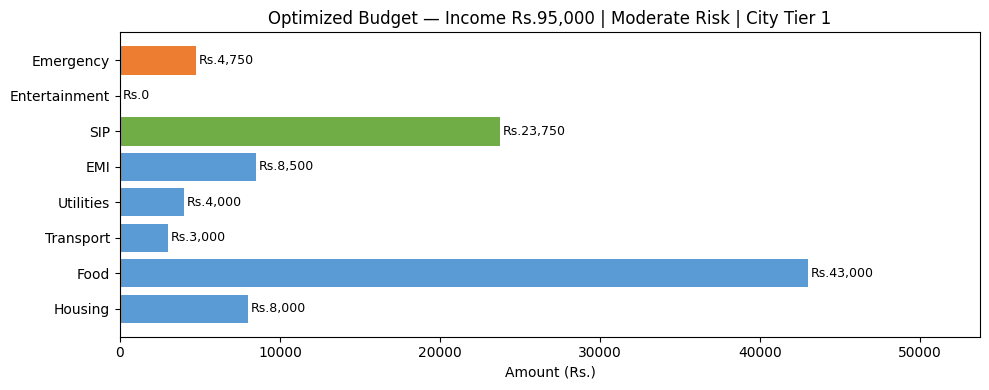

Total allocated: Rs.95,000 (income: Rs.95,000)
SIP maximised at: Rs.23,750/month (25% of income)


In [4]:
from aria.module1_personal_finance.budget_optimize import optimize_budget
from aria.module1_personal_finance.schemas import RiskProfile
import matplotlib.pyplot as plt

income = 95000
b = optimize_budget(income, 8500, 1, RiskProfile(label='Moderate', confidence=0.7), 1.0)

categories = ['Housing','Food','Transport','Utilities','EMI','SIP','Entertainment','Emergency']
amounts    = [b.housing, b.food, b.transport, b.utilities, b.emi, b.sip, b.entertainment, b.emergency_fund_add]
colors     = ['#5B9BD5','#5B9BD5','#5B9BD5','#5B9BD5','#5B9BD5','#70AD47','#70AD47','#ED7D31']

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(categories, amounts, color=colors)
for bar, amt in zip(bars, amounts):
    ax.text(bar.get_width() + 200, bar.get_y() + bar.get_height()/2,
            f'Rs.{amt:,.0f}', va='center', fontsize=9)
ax.set_xlabel('Amount (Rs.)')
ax.set_title(f'Optimized Budget — Income Rs.{income:,} | Moderate Risk | City Tier 1')
ax.set_xlim(0, max(amounts) * 1.25)
plt.tight_layout()
plt.show()
print(f'Total allocated: Rs.{sum(amounts):,.0f} (income: Rs.{income:,})')
print(f'SIP maximised at: Rs.{b.sip:,.0f}/month ({b.sip/income:.0%} of income)')

## 5. Isolation Forest — Anomaly Detection

In [5]:
from aria.module1_personal_finance.schemas import Transaction, UserFinancialInput
from aria.module1_personal_finance.fraud_detect import detect_for_user
from datetime import date, timedelta

today = date.today()
transactions = [
    Transaction(date=today-timedelta(days=5),  category='food',     amount=450,   channel='upi'),
    Transaction(date=today-timedelta(days=4),  category='food',     amount=380,   channel='upi'),
    Transaction(date=today-timedelta(days=3),  category='food',     amount=520,   channel='upi'),
    Transaction(date=today-timedelta(days=2),  category='shopping', amount=2800,  channel='card'),
    Transaction(date=today-timedelta(days=1),  category='shopping', amount=85000, channel='card'),  # anomalous!
    Transaction(date=today,                    category='travel',   amount=1500,  channel='upi'),
]
inp = UserFinancialInput(user_id=1, monthly_income=95000, transactions=transactions)
flags = detect_for_user(inp)

print(f'Transactions analysed: {len(transactions)}')
print(f'Anomalies flagged:     {len(flags)}')
for f in flags:
    print(f'\n  FLAGGED: Rs.{f.transaction.amount:,.0f} ({f.transaction.category})')
    print(f'  Reason:  {f.reason}')
    print(f'  Score:   {f.score:.1f}x above median')

Transactions analysed: 6
Anomalies flagged:     1

  FLAGGED: Rs.85,000 (shopping)
  Reason:  Single transaction exceeds 50% of monthly income.
  Score:   1.9x above median


## 6. LSTM Spending Forecast (3-month)

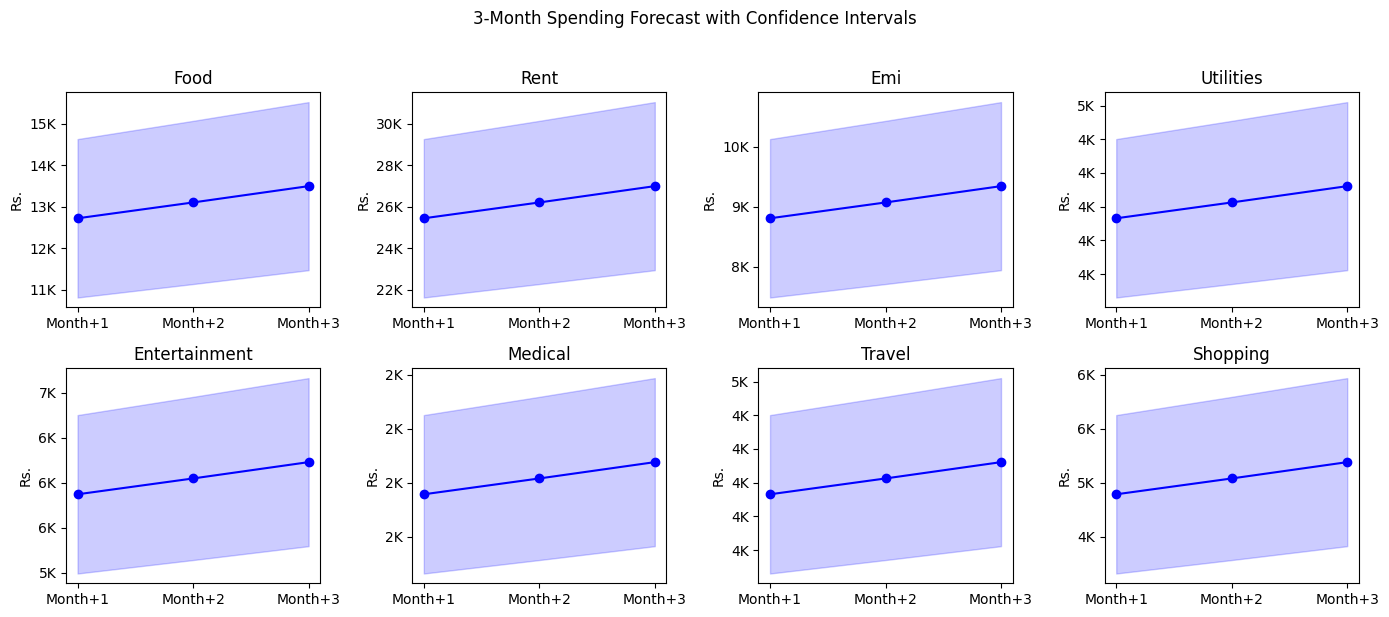

Forecast total spend next month: Rs.67,516


In [6]:
from aria.module1_personal_finance.spend_forecast import _heuristic_forecast
from aria.module1_personal_finance.schemas import UserFinancialInput
import matplotlib.pyplot as plt
import numpy as np

inp = UserFinancialInput(user_id=1, monthly_income=95000)
forecasts = _heuristic_forecast(inp)

months = ['Month+1', 'Month+2', 'Month+3']
fig, axes = plt.subplots(2, 4, figsize=(14, 6))
axes = axes.flatten()
for i, fc in enumerate(forecasts):
    axes[i].plot(months, fc.forecast, 'b-o', label='Median')
    axes[i].fill_between(months, fc.lower_ci, fc.upper_ci, alpha=0.2, color='blue', label='80% CI')
    axes[i].set_title(fc.category.capitalize())
    axes[i].set_ylabel('Rs.')
    axes[i].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
plt.suptitle('3-Month Spending Forecast with Confidence Intervals', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

total_next = sum(c.forecast[0] for c in forecasts)
print(f'Forecast total spend next month: Rs.{total_next:,.0f}')

## 7. SBERT + FAISS Concept Retrieval

In [7]:
from aria.module2_tutor.concept_retriever import retrieve

queries = [
    'what is compounding',
    'SIP monthly investment',
    'how to save tax 80C',
    'retirement planning',
    'home loan EMI',
    'stock market risk',
]

print(f'{'Query':35}  Top Match (score)           Runner-up')
print('-'*85)
for q in queries:
    hits = retrieve(q, k=2)
    top  = f'{hits[0]["canonical_name"]} ({hits[0]["score"]:.2f})'
    sec  = hits[1]['canonical_name'] if len(hits)>1 else '—'
    print(f'{q:35}  {top:30}  {sec}')

Query                                Top Match (score)           Runner-up
-------------------------------------------------------------------------------------


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

2026-04-29 14:44:35.324 | INFO     | aria.shared.vector_store:_encoder:15 - SBERT loaded on cpu


what is compounding                  Compound Interest (0.59)        CAGR
SIP monthly investment               Systematic Investment Plan (0.78)  Lump Sum Investment
how to save tax 80C                  Section 80C (0.51)              Section 80D
retirement planning                  Retirement Corpus (0.51)        Withdrawal Rate
home loan EMI                        EMI (0.59)                      Loan Amortization
stock market risk                    Diversification (0.47)          Beta


## 8. Deep Knowledge Tracing (DKT) — Mastery Evolution

In [ ]:
import torch
import matplotlib.pyplot as plt
from aria.module2_tutor.knowledge_tracer import DKT, mastery_vector

model = DKT(n_concepts=50)
model.load_state_dict(torch.load('models/lstm_kt.pt', map_location='cpu', weights_only=True))
model.eval()

# Simulate a learner studying compound interest (concept 1)
interactions = [
    {'concept_id': 1, 'is_correct': 0},
    {'concept_id': 1, 'is_correct': 0},
    {'concept_id': 1, 'is_correct': 1},
    {'concept_id': 2, 'is_correct': 1},  # related concept
    {'concept_id': 1, 'is_correct': 1},
    {'concept_id': 1, 'is_correct': 1},
]

masteries = []
for i in range(len(interactions)+1):
    mv = mastery_vector(model, interactions[:i])
    masteries.append(mv[1])  # compound interest mastery

plt.figure(figsize=(9, 4))
plt.plot(masteries, 'b-o', linewidth=2, markersize=8)
results = ['Start','Wrong','Wrong','Correct','Related\nCorrect','Correct','Correct']
for i, (m, r) in enumerate(zip(masteries, results)):
    plt.annotate(r, (i, m), textcoords='offset points', xytext=(0,12), ha='center', fontsize=8)
plt.axhline(0.7, color='green', linestyle='--', label='Mastery threshold (70%)')
plt.xlabel('Interaction Number'); plt.ylabel('Mastery Probability')
plt.title('DKT: Compound Interest Mastery Evolution')
plt.ylim(0, 1); plt.legend(); plt.tight_layout()
plt.show()
print(f'Final mastery after 6 interactions: {masteries[-1]:.3f}')

## 9. DQN Teaching Agent — Action Selection Policy

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from stable_baselines3 import DQN
from aria.module2_tutor.teaching_agent import ACTIONS

dqn = DQN.load('models/dqn_teacher', device='cpu')

# Show how action changes with mastery level
mastery_levels = np.linspace(0, 1, 20)
actions_taken  = []
for m in mastery_levels:
    state = np.array([m, 0.7, 0.6, 0.0, 0.4], dtype=np.float32)
    action, _ = dqn.predict(state, deterministic=True)
    actions_taken.append(ACTIONS[int(action)])

print('Mastery → Teaching Action:')
print('-'*45)
last = None
for m, a in zip(mastery_levels, actions_taken):
    if a != last:
        print(f'  {m:.0%}+  →  {a}')
        last = a

# Bar chart of action frequency
from collections import Counter
counts = Counter(actions_taken)
fig, ax = plt.subplots(figsize=(9, 3))
ax.bar(counts.keys(), counts.values(), color='#5B9BD5')
ax.set_title('DQN Action Distribution across all mastery levels')
ax.set_ylabel('Times selected')
plt.tight_layout(); plt.show()

## 10. NER Extractor — Financial Entity Recognition

In [ ]:
from aria.shared.ner_extractor import extract

sentences = [
    'My salary is Rs.95000 and I pay an EMI of Rs.8500 per month',
    'I earn 1.2 lakh monthly, invest 50k in SIP at 12% for 10 years',
    'I want 80C deduction and my portfolio is 10cr with 8.5% returns',
    'I am 32 years old and save 2.5L annually in PPF and ELSS',
]

for sent in sentences:
    e = extract(sent)
    print(f'Input:    {sent}')
    print(f'  Amounts:  {[f"Rs.{a:,.0f}" for a in e.amounts]}')
    if e.percents: print(f'  Percents: {e.percents}')
    if e.products: print(f'  Products: {e.products}')
    if e.sections: print(f'  Sections: {e.sections}')
    if e.horizons: print(f'  Horizons: {e.horizons}')
    if e.ages:     print(f'  Ages:     {e.ages}')
    print()

## 11. Profile Auto-Update from Natural Language

In [ ]:
from aria.shared.profile_updater import extract_display, detect_and_update
from aria.shared.user_store import get_financial_profile, init_db
init_db()

sentences = [
    'My salary is Rs.95000 and I have an EMI of Rs.8500',
    'I am 28 years old and live in Chennai',
    'I have 2 dependents and prefer new tax regime',
    'I have 3 months emergency fund',
]

print('Extracting financial profile from natural language:\n')
for sent in sentences:
    detected = extract_display(sent)
    changed  = detect_and_update(1, sent)
    print(f'Input:    "{sent}"')
    print(f'Detected: {detected}')
    if changed: print(f'DB saved: {list(changed.keys())}')
    print()

fp = get_financial_profile(1)
print('Final profile in DB:')
print(f'  Income: Rs.{fp.monthly_income:,.0f}')
print(f'  EMI:    Rs.{fp.existing_emi:,.0f}')
print(f'  Regime: {fp.tax_regime}')

## 12. Complete M1 Pipeline (All Models Together)

In [ ]:
import time
from aria.module1_personal_finance.ingest import build_m1_input
from aria.module1_personal_finance.orchestrator import run

t0 = time.time()
inp  = build_m1_input(1, 'plan my budget and SIP')
resp = run(inp)
elapsed = time.time() - t0

print(f'Pipeline completed in {elapsed:.2f}s\n')
print('=== RISK PROFILE (XGBoost) ===')
print(f'  Label:      {resp.risk.label}')
print(f'  Confidence: {resp.risk.confidence:.0%}')
print(f'  SHAP drivers: {", ".join(f+"="+f"{v:+.2f}" for f,v in resp.risk.top_features[:3])}')

print('\n=== BUDGET (Linear Programming) ===')
print(f'  Housing:   Rs.{resp.budget.housing:,.0f}')
print(f'  Food:      Rs.{resp.budget.food:,.0f}')
print(f'  SIP:       Rs.{resp.budget.sip:,.0f}')
print(f'  EMI:       Rs.{resp.budget.emi:,.0f}')

print('\n=== SIP PLAN ===')
print(f'  Monthly SIP:  Rs.{resp.sip_plan.monthly_sip:,.0f}')
print(f'  Equity/Debt:  {resp.sip_plan.fund_split["equity"]:.0%} / {resp.sip_plan.fund_split["debt"]:.0%}')

print('\n=== FORECAST (LSTM heuristic) ===')
for fc in resp.forecast[:3]:
    print(f'  {fc.category:15} next month: Rs.{fc.forecast[0]:,.0f}')

print(f'\n=== ANOMALIES (Isolation Forest) ===')
print(f'  Flags: {len(resp.anomalies)} (no transactions loaded in this run)')

## 13. FinGPT — Live LLM Generation (requires server)
Start server first: `uvicorn aria.shared.fingpt_server:app --port 7860`

In [ ]:
from aria.shared.fingpt_client import health, generate_stream

if not health():
    print('FinGPT server not running.')
    print('Start it with:')
    print('  E:\\dependencies\\venv\\Scripts\\python.exe -m uvicorn aria.shared.fingpt_server:app --port 7860')
else:
    print('FinGPT is live. Generating explanation...\n')
    prompt = 'Compound interest is the concept where'
    print(f'Prompt: "{prompt}"\nResponse:')
    full = ''
    for token in generate_stream(prompt, max_new_tokens=120, temperature=0.75):
        print(token, end='', flush=True)
        full += token
    print(f'\n\nGenerated {len(full.split())} words')

## 14. Model Accuracy Summary

In [ ]:
import pathlib

print('=== TRAINED MODEL FILES ===')
from config.paths import XGB_RISK_PATH, LSTM_SPEND_PATH, ISO_FOREST_PATH, LSTM_KT_PATH, DQN_TEACHER_PATH
models = {
    'XGBoost Risk Profiler':      (XGB_RISK_PATH,           'CV macro-F1 = 1.000 (synthetic labels)'),
    'LSTM Spend Forecaster':      (LSTM_SPEND_PATH,         'Val quantile loss = 0.0040'),
    'Isolation Forest':           (ISO_FOREST_PATH,         '827K transactions, contamination=2%'),
    'DKT Knowledge Tracer':       (LSTM_KT_PATH,            'Val BCE loss = 0.0624'),
    'DQN Teaching Agent':         (DQN_TEACHER_PATH+'.zip', '200,000 timesteps'),
    'FAISS Concept Index':        ('data/vector_store/concepts/index.faiss', '50 concepts, SBERT embeddings'),
}
for name, (path, metric) in models.items():
    p = pathlib.Path(path)
    size = p.stat().st_size // 1024 if p.exists() else 0
    status = 'OK' if p.exists() else 'MISSING'
    print(f'  {status}  {name:<30} {size:>5} KB  |  {metric}')

print('\n=== DATASET SIZES ===')
txns = list(pathlib.Path('data/raw/transactions_synthetic').glob('*.parquet'))
import json
kb   = json.loads(pathlib.Path('data/raw/concepts_kb/concepts.json').read_text())
seqs = json.loads(pathlib.Path('data/raw/kt_sequences/kt_sequences.json').read_text())
print(f'  Synthetic users:     {len(txns)}')
print(f'  Financial concepts:  {len(kb)}')
print(f'  KT sequences:        {len(seqs)}')